# Análisis


In [1]:
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Lectura y visualización del CSV final
df_final = pd.read_csv('../files/hr_final.csv', index_col = 0)
df_final.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,41,True,Travel Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,0,8,0,1,6,4,0,5
2,49,False,Travel Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,1,10,3,3,10,7,1,7
4,37,True,Travel Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,True,15,3,2,0,7,3,3,0,0,0,0
5,33,False,Travel Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,True,11,3,3,0,8,3,3,8,7,3,0
7,27,False,Travel Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,False,12,3,4,1,6,3,3,2,2,2,2


In [3]:
# Comprobación de tipos correctos del dataset
df_final.info()

<class 'pandas.DataFrame'>
Index: 1470 entries, 1 to 2068
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   bool   
 2   BusinessTravel            1470 non-null   str    
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   str    
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   str    
 8   EnvironmentSatisfaction   1470 non-null   int64  
 9   Gender                    1470 non-null   str    
 10  HourlyRate                1470 non-null   int64  
 11  JobInvolvement            1470 non-null   int64  
 12  JobLevel                  1470 non-null   int64  
 13  JobRole                   1470 non-null   str    
 14  JobSatisfaction         

## Valores estadísticos básicos de las variables numéricas:

In [4]:
#Función para calcular el resumen estadístico de una variable:
def resumen_variable(df, columna):

    serie_original = df[columna]
    serie = serie_original.dropna()

    # Calculo de las estadísticas básicas
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()
    desviacion = serie.std()
    minimo = serie.min()
    maximo = serie.max()
    varianza = serie.var()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    rango_intercuartilico = q3 - q1
    rango = maximo - minimo
    lower = q1  - rango_intercuartilico*1.5
    upper = q3 + rango_intercuartilico*1.5
    outliers = df.loc[serie[(serie < lower) | (serie > upper)].index]

    if media != 0:
        coef_variacion = (desviacion / media) * 100
    else:
        coef_variacion = np.nan

    # Creación de dataframe con los valores obtenidos
    resumen = pd.DataFrame({
        "variable": [columna],
        "media": [round(media, 2)],
        "mediana": [round(mediana, 2)],
        "moda": [moda.iloc[0] if len(moda) > 0 else np.nan],
        "desviacion_estandar": [round(desviacion, 2)],
        "minimo": [round(minimo, 2)],
        "maximo": [round(maximo, 2)],
        "varianza": [round(varianza, 2)],
        "q1": [round(q1, 2)],
        "q3": [round(q3, 2)],
        "rango_intercuartilico": [round(rango_intercuartilico, 2)],
        "rango": [round(rango, 2)],
        "coeficiente_variacion": [round(coef_variacion, 2)],
        "num_outliers": [outliers.shape[0]]
    })

    return resumen

In [5]:
# Función para automatizar la extracción de información de cada variable numérica
def resumen_variables_numericas(df, columnas_numericas):

    # Creación de lista vacía
    tablas_resumen = []

    # Bucle que ejecuta la función anterior
    for columna in columnas_numericas:
        resumen = resumen_variable(df, columna)
        # Añade a la lista vacía cada variable
        tablas_resumen.append(resumen)

    # Concatenación de los dataframes obtenidos en la funcion anterior
    resumen_total = pd.concat(tablas_resumen, ignore_index=True)

    return resumen_total

In [6]:
# Lista de variables numéricas
variables_numericas = df_final.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_numericas

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [7]:
# Ejecución de las funciones para creación de dataframe con valores estadísticos básicos
resumen_total = resumen_variables_numericas(df_final, variables_numericas)
resumen_total

,variable,media,mediana,moda,desviacion_estandar,minimo,maximo,varianza,q1,q3,rango_intercuartilico,rango,coeficiente_variacion,num_outliers
0,Age,36.95,36.0,37.0,8.87,18.0,60.0,78.62,31.00,42.00,11.00,42.0,24.00,14
1,DailyRate,802.49,802.0,691.0,403.51,102.0,1499.0,162819.59,465.00,1157.00,692.00,1397.0,50.28,0
2,DistanceFromHome,9.19,7.0,2.0,8.11,1.0,29.0,65.72,2.00,14.00,12.00,28.0,88.19,0
3,Education,2.91,3.0,3.0,1.02,1.0,5.0,1.05,2.00,4.00,2.00,4.0,35.16,0
4,EnvironmentSatisfaction,2.72,3.0,3.0,1.09,1.0,4.0,1.19,2.00,4.00,2.00,3.0,40.16,0
5,HourlyRate,65.89,66.0,66.0,20.33,30.0,100.0,413.29,48.00,83.75,35.75,70.0,30.85,0
6,JobInvolvement,2.73,3.0,3.0,0.71,1.0,4.0,0.51,2.00,3.00,1.00,3.0,26.07,0
7,JobLevel,2.06,2.0,1.0,1.11,1.0,5.0,1.23,1.00,3.00,2.00,4.0,53.63,0
8,JobSatisfaction,2.74,3.0,3.0,1.09,1.0,4.0,1.20,2.00,4.00,2.00,3.0,39.99,0
9,MonthlyIncome,6483.52,4907.0,4907.0,4689.45,1009.0,19999.0,21990945.44,2926.75,8233.75,5307.00,18990.0,72.33,120


**Análisis de las variables numéricas:**

* La tabla obtenida sirve para ver todos los valores estadísticos del dataset. 
* Esto permite observar la relación entre dichos valores, como la media y la mediana o la desviación estándar:
    - La mayoría de las variables presentan una media y mediana parecidas. En caso contrario destaca `MonthlyIncome`.
    - Varias columnas presentan outliers, algunas con valores bajos como `Age` o `YearsWithCurrManager`. `PerformanceRating` a pesar de tener solo dos valores [3, 4], presenta todos los 4 como outliers. Otras columnas con valores muy altos son `TrainingTimesLastYear` y `MonthlyIncome`.

## Valores estadísticos básicos de las variables categóricas:


In [8]:
# Creación de lista de variables categóricas
variables_categoricas = df_final.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
variables_categoricas

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [9]:
# Conteo de variables categóricas
len(variables_categoricas)

8

In [10]:
# Función para extraer la frecuencia absoluta y relativa de cada variable categórica
def tablas_categoricas(df, columnas_categoricas):
    tablas = {}

    for columna in columnas_categoricas:
        # Cálculo de las frecuencias
        frecuencia_absoluta = df[columna].value_counts(dropna=False)
        frecuencia_relativa = df[columna].value_counts(normalize=True, dropna=False) * 100

        # Creación de dataframe con las frecuencias
        tabla = pd.DataFrame({
            "frecuencia_absoluta": frecuencia_absoluta,
            "frecuencia_relativa": frecuencia_relativa.round(2)
        })

        # Índice en variable categórica
        tabla.index.name = columna
        tablas[columna] = tabla

        print(f"\nVariable: {columna}")
        display(tabla)

In [11]:
# Ejecución de la función para extraer los valores de cada variable
tablas_categoricas(df_final, variables_categoricas)


Variable: Attrition


,frecuencia_absoluta,frecuencia_relativa
Attrition,,
False,1233,83.88
True,237,16.12



Variable: BusinessTravel


,frecuencia_absoluta,frecuencia_relativa
BusinessTravel,,
Travel Rarely,951,64.69
Travel Frequently,263,17.89
Non-Travel,139,9.46
unknown,117,7.96



Variable: Department


...

,frecuencia_absoluta,frecuencia_relativa
JobRole,,
Sales Executive,326,22.18
Research Scientist,292,19.86
Laboratory Technician,259,17.62
Manufacturing Director,145,9.86
Healthcare Representative,131,8.91
Manager,102,6.94
Sales Representative,83,5.65
Research Director,80,5.44
Human Resources,52,3.54



Variable: MaritalStatus


,frecuencia_absoluta,frecuencia_relativa
MaritalStatus,,
Married,606,41.22
Single,436,29.66
Divorced,296,20.14
unknown,132,8.98



Variable: OverTime


,frecuencia_absoluta,frecuencia_relativa
OverTime,,
False,1065,72.45
True,405,27.55


**Análisis de las variables categóricaS:**

* Las tablas obtenidas sirven para representar los valores de frecuencia absoluta y relativa de las diferentes variables.
    - En `Attrition` observamos que la mayoría del personal (83.88%) continúa en la empresa.
    - Más de la mitad (64.69%) de los trabajadores viajan ocasionalmente.
    - Los departamentos más representativos son `Research & Development` (63.88%) y `Sales` (29.86%).
    - La mayoría del personal tienen estudios relativos a `Life Sciences` (39.52%) y `Medical` (30.41%).
    - La columna `Gender` no muestra diferencia notable entre las categorías.
    - En `JobRole` las categorías están más repartidas, pero destacan tres con valores superiores al 15%: `Sales Executive`, `Research Scientist`, `Laboratory Technician`.
    - En `MaritalStatus` existe un reparto escalonado, con mayoría (41.22%) en el estado `Married`.
    - La gran mayoría de los trabajadores no realizan horas extra (72.45%).

## Visualización de las variables numéricas:

In [12]:
# División de variables numéricas en diferentes listas, para mejorar la visualización
variables_numericas1 = ['DistanceFromHome','JobLevel','PerformanceRating','StockOptionLevel','TrainingTimesLastYear']
variables_numericas2= ['Age', 'Education','NumCompaniesWorked']
variables_encuesta = ['EnvironmentSatisfaction', 'JobInvolvement','JobSatisfaction','RelationshipSatisfaction','WorkLifeBalance']
variables_salario = ['DailyRate','HourlyRate', 'MonthlyRate','MonthlyIncome','PercentSalaryHike']
variables_tiempo = [ 'TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']

In [13]:
# Función para la visualización de los diferentes tipos de variables numericas
def visualizacion_numericas(df, variables):
    
    # Conteo de variables para tamaño de figura y numero de filas
    filas= len(variables)
    fig, axes = plt.subplots(nrows=filas, ncols=2, figsize=(14, filas*4))

    for i, variable in enumerate(variables):

        # Cálculo de valores estadísticos para el dibujo
        media = df[variable].mean()
        mediana = df[variable].median()
        moda = df[variable].mode()[0]
        std = df[variable].std()
        
        valores_unicos = df[variable].nunique()
        
        # Se calcula los bins dependiendo de los valores en la variable
        if valores_unicos <= 10:
            bins = np.arange(df[variable].min(), df[variable].max() + 2) - 0.5
        else:
            bins = 30

        # Histograma
        sns.histplot(
            data=df,
            x=variable,
            bins=bins,
            kde=True,
            color='cadetblue',
            ax=axes[i, 0]
        )

        # Pintado de media, mediana y moda
        axes[i, 0].axvline(media, color="red", linestyle="-", linewidth=2, label=f"Media: {media:.2f}")
        axes[i, 0].axvline(mediana, color="green", linestyle="-", linewidth=2, label=f"Mediana: {mediana:.2f}")
        axes[i, 0].axvline(moda, color="purple", linestyle="-", linewidth=2, label=f"Moda: {moda:.2f}")
        
        axes[i, 0].set_title(f"Histograma de {variable}")
        axes[i, 0].set_xlabel(variable)
        axes[i, 0].set_ylabel("Frecuencia")
        axes[i, 0].legend(loc='upper right', fontsize=8, framealpha=0.8)
        
        # Boxplot
        sns.boxplot(
            data=df,
            x=variable,
            ax=axes[i, 1],
            color='cadetblue',
            medianprops=dict(color='darkred', linewidth=2)
        )

        # ±1 desviación estándar
        axes[i, 1].axvspan(media - std, media + std, color='orange', alpha=0.08, 
                label=f'±1 Std Dev ({std:,.2f})')
        axes[i, 1].legend()
        
        # Título de la gráfica 
        axes[i, 1].set_title(f"Boxplot de {variable}")
        axes[i, 1].set_xlabel(variable)

    plt.tight_layout()
    plt.show()

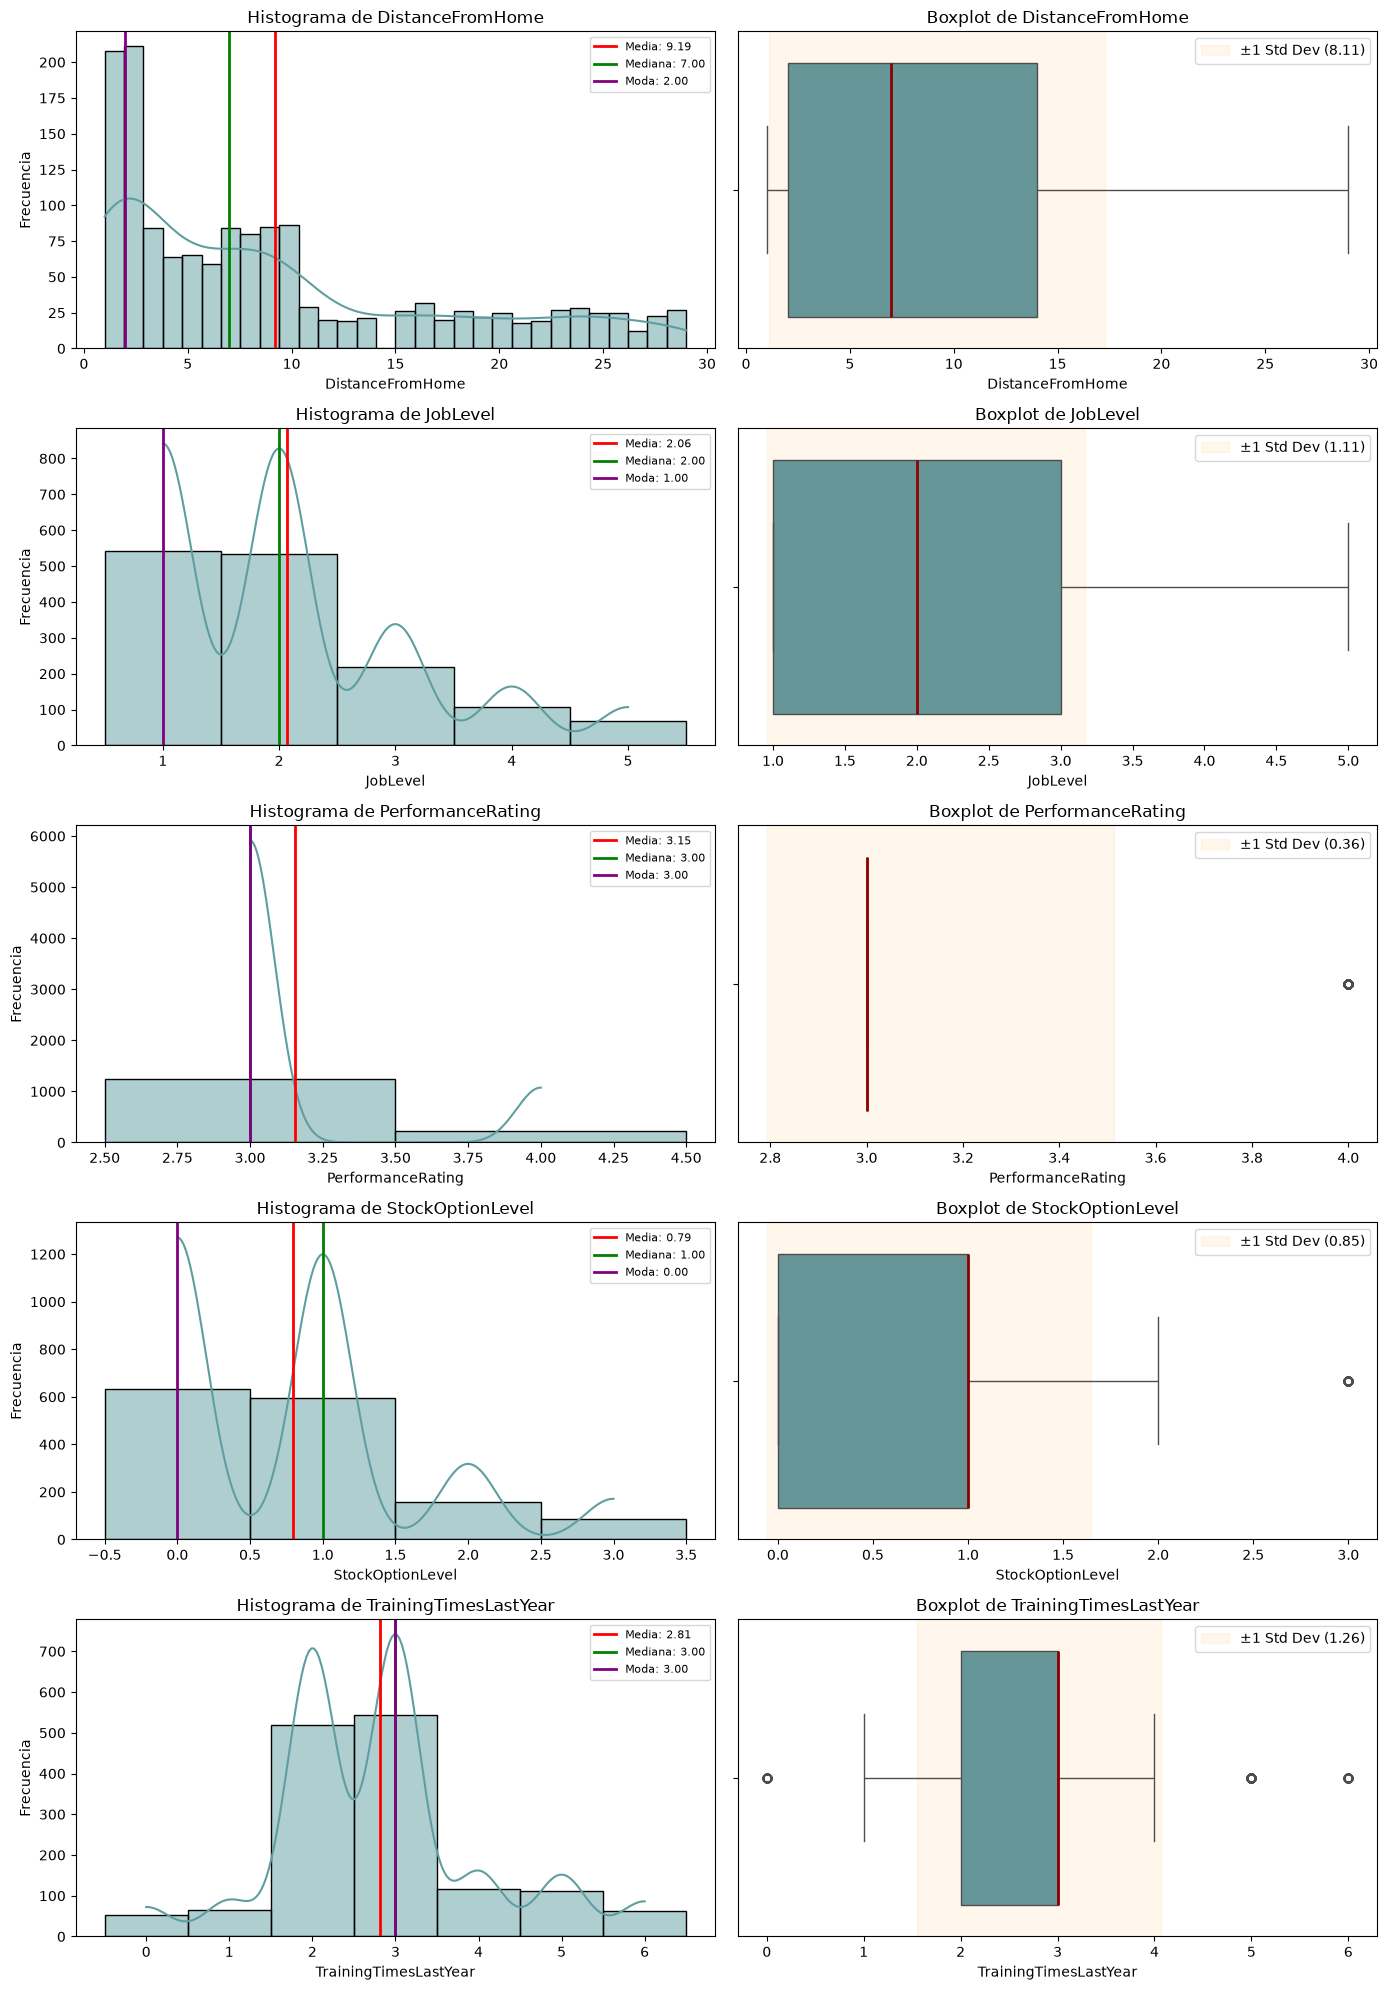

In [14]:
# Ejecución de la función para variables numéricas 1
visualizacion_numericas(df_final, variables_numericas1)

**Análisis de visualización de variables numéricas 1:**
* *`DistanceFromHome`, `JobLevel`,`PerformanceRating`,`StockOptionLevel` y `TrainingTimesLastYear`*

- `DistanceFromHome` presenta una media, mediana y moda más separadas.
- La mayoría de los trabajadores están entre los valores [1,2] de `JobLevel`, los rangos más bajos.
- Se visualiza lo anteriormente mencionado sobre `PerformanceRating`, donde moda, media y mediana están en el valor 3 y el 4 se considera outliers.
- Destaca que en `StockOptionLevel` la moda es 0, desviando el rango intercuartículo hacia los valores más bajos.
- En `TrainingTimesLastYear` se observa que la mayoría de los empleados han recibido un número de formaciones adecuadas durante el último año.

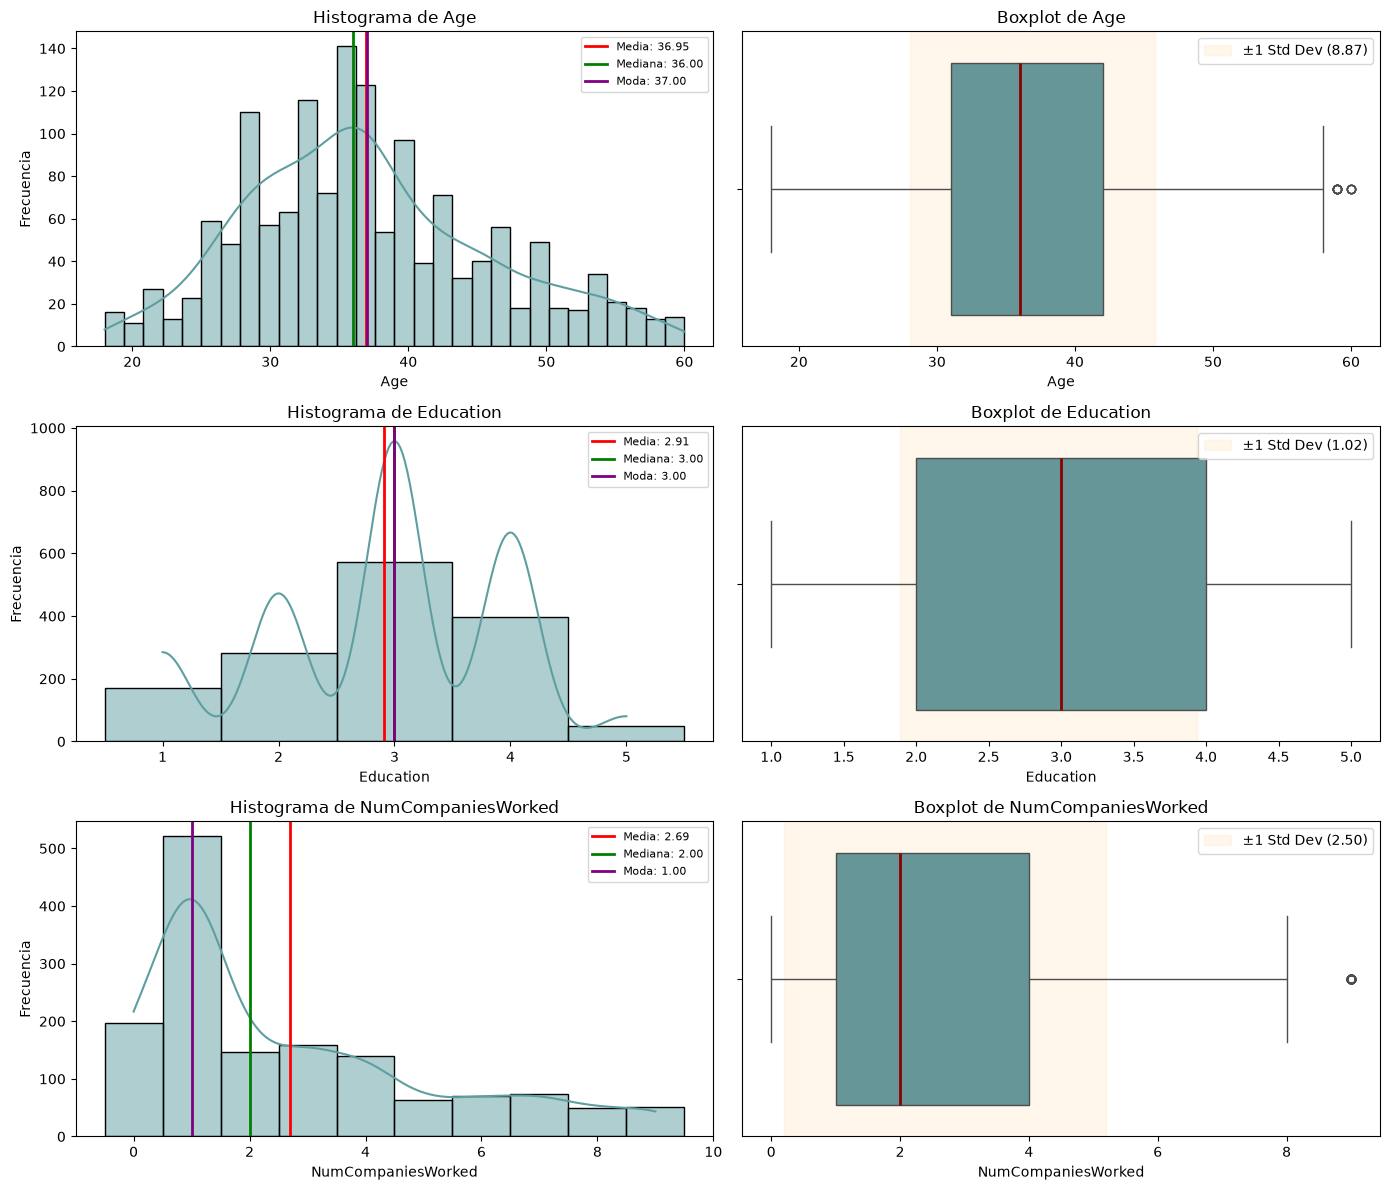

In [15]:
# Ejecución de la función para variables numéricas 2
visualizacion_numericas(df_final, variables_numericas2)

**Análisis de visualización de variables numéricas 2:**
* *`Age`, `Education` y `NumCompaniesWorked`*

- La columna `Age` presenta una distribución normal, con forma de campana de Gauss, indicando que media, mediana y moda están muy cerca.
- `Education` representa el nivel educativo en escala numérica, indicando que la mayoría de los empleados tienen un nivel de estudios de grado/licenciatura.
- En `NumCompaniesWorked` observamos que la mayoría de los empleados no han trabajado en muchas compañías antes que en la del estudio.

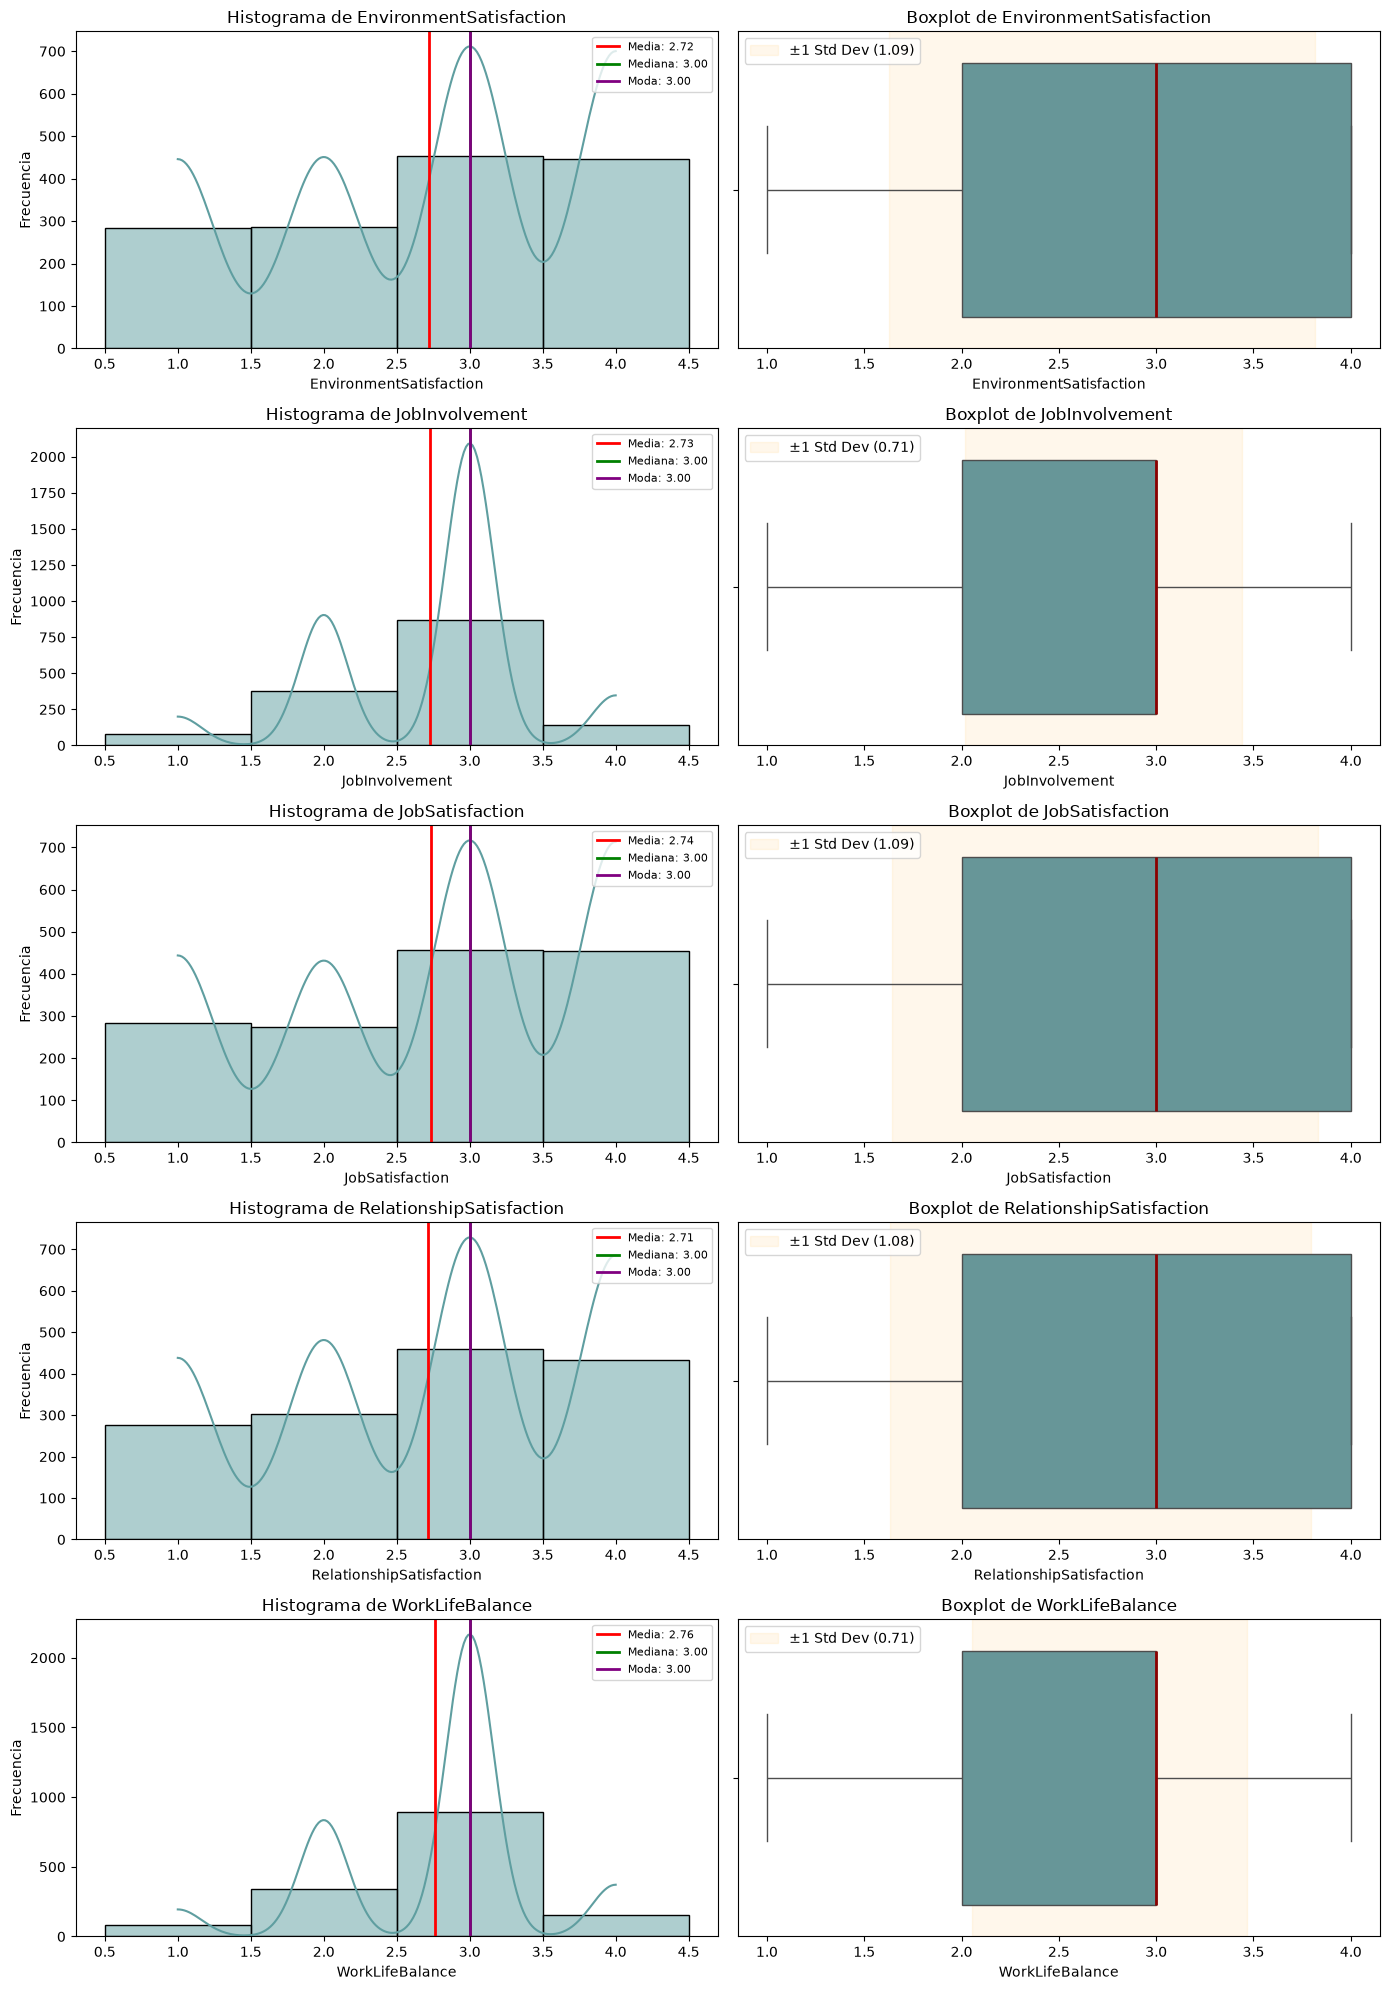

In [16]:
# Ejecución de la función para variables encuesta
visualizacion_numericas(df_final, variables_encuesta)

**Análisis de visualización de variables encuesta:**
* *`EnvironmentSatisfaction`, `JobInvolvement`,`JobSatisfaction`,`RelationshipSatisfaction` y `WorkLifeBalance`*

- `EnvironmentSatisfaction`, `JobSatisfaction` y `RelationshipSatisfaction` presentan una distribución similar, con un reparto de votos mayoritario entre los valores 2 y 4
- En `JobInvolvement` y `WorkLifeBalance` hay una tendencia al voto con valor 3.
- En las cinco encuestas, la mediana y moda están en el valor 3, indicando una buena satisfacción por parte de la mayoría de los trabajadores.

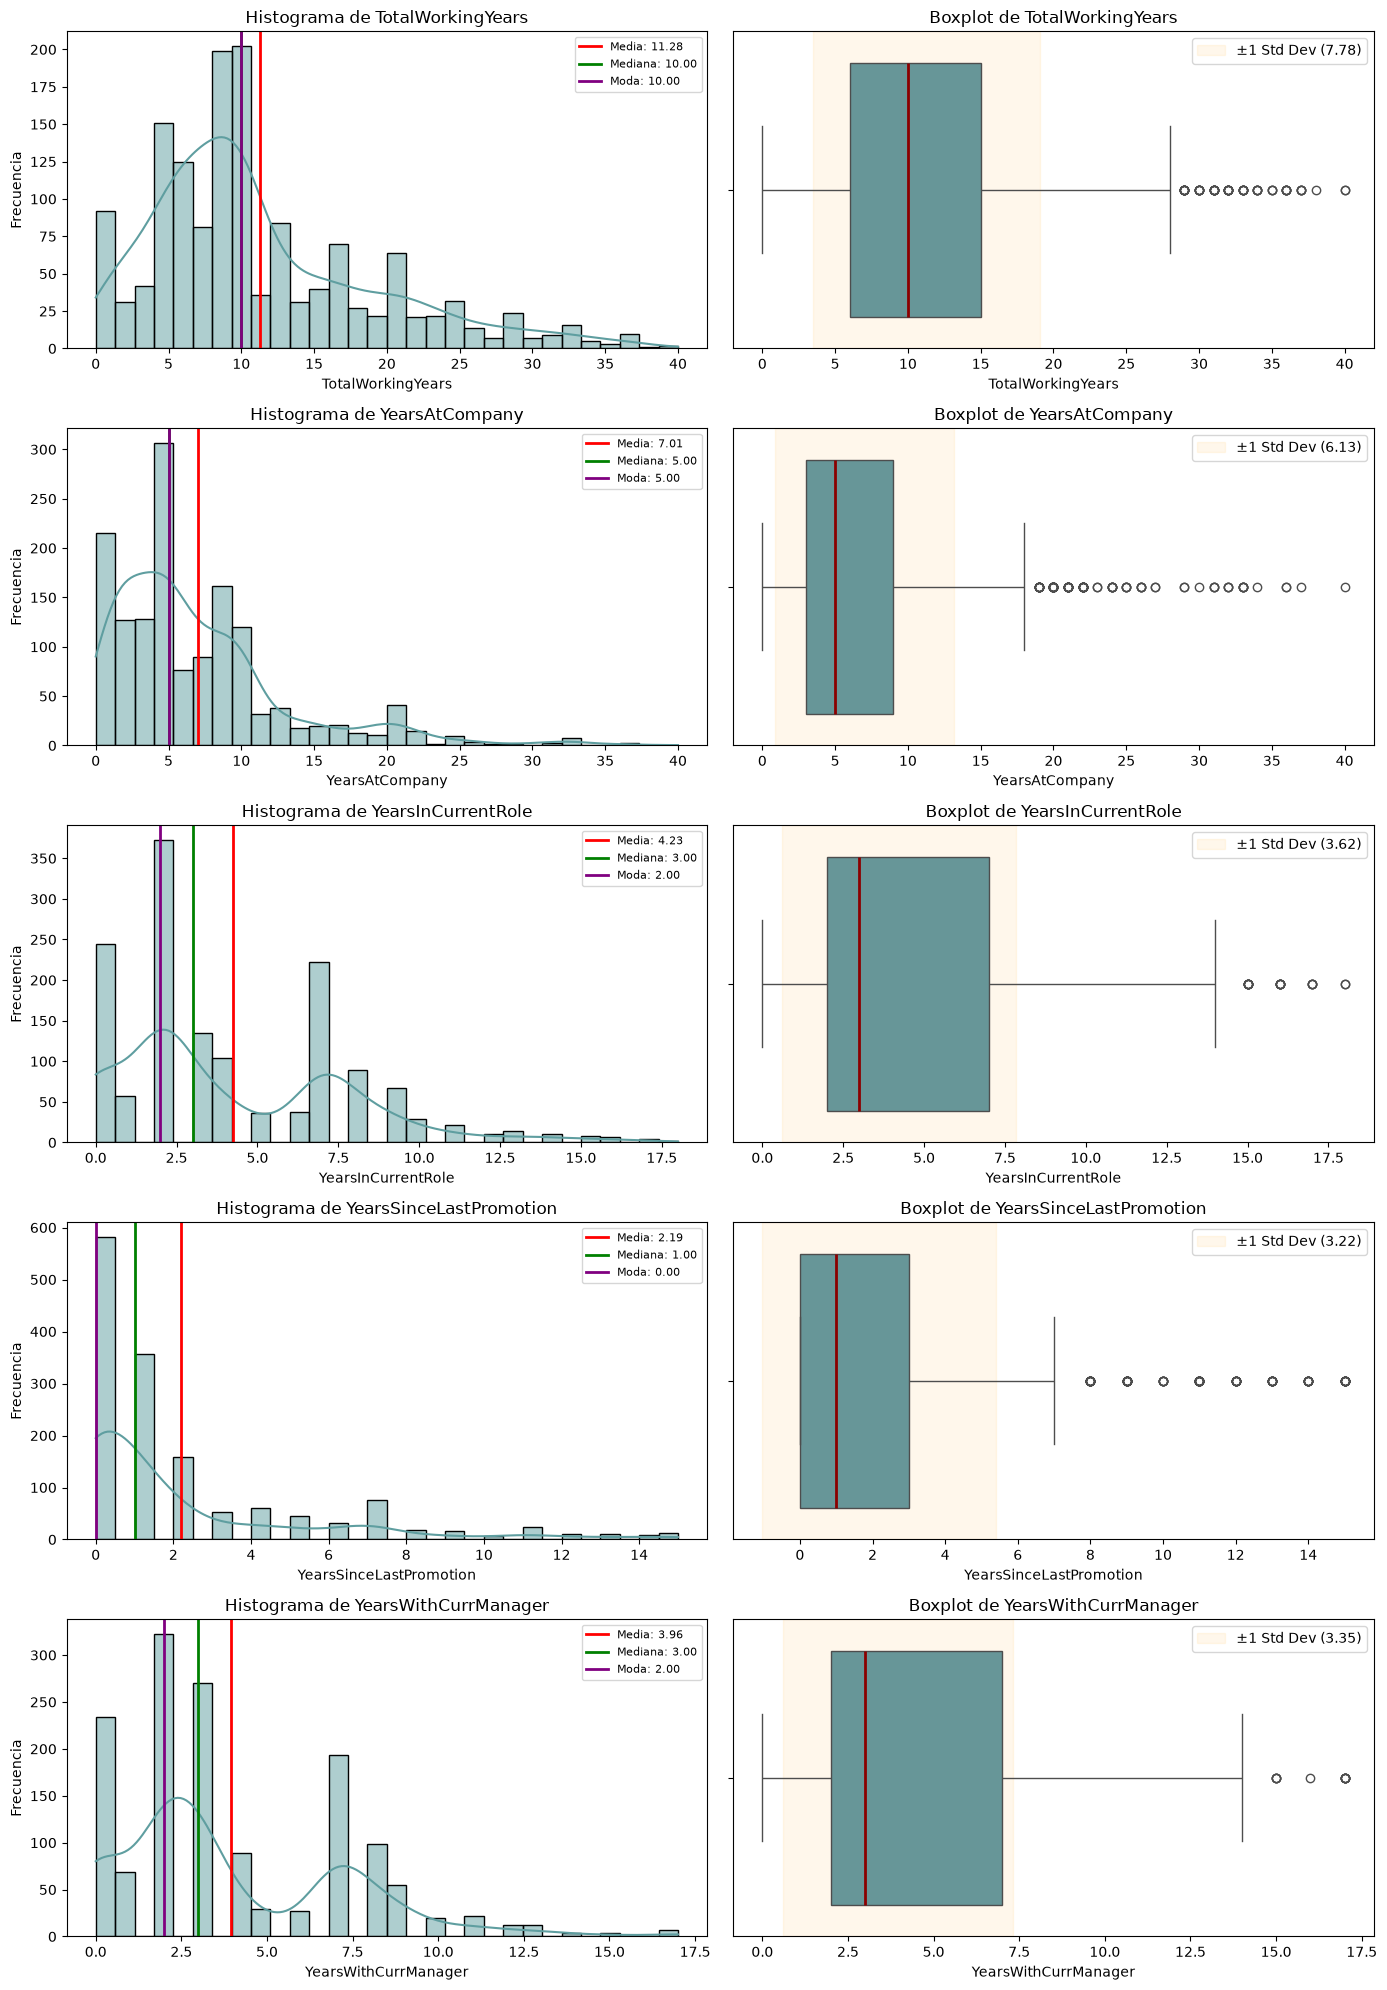

In [17]:
# Ejecución de la función para variables tiempo
visualizacion_numericas(df_final, variables_tiempo)

**Análisis de visualización de variables tiempo:**
* *`TotalWorkingYears`,`YearsAtCompany`,`YearsInCurrentRole`,`YearsSinceLastPromotion` y `YearsWithCurrManager`*

- Todas las variables de tiempo presentan outliers y una posible correlación entre ellas.
- Todas están sesgadas a la derecha con una mediana inferior a la media. Un patrón indicativo de que la mayoría de los empleados tienen poco tiempo en el mundo laboral.
- `YearsInCurrentRole` y `YearsWithCurrManager` presentan un doble pico. Indicativo de que hay personas que rotan mucho y otras que rotan muy poco.
- Lógica de datos: `TotalWorkingYears` tiene una media mayor a `YearsAtCompany`, que a su vez es mayor al resto.

In [18]:
#Cruce de variables YearsAtCompany y YearsSinceLastPromotion

def visualizacion_promocion_antiguedad(df):
    
    # Creamos grupos de antigüedad en la empresa
    def grupo_antiguedad(x):
        if x <= 2:
            return '0-2 años'
        elif x <= 5:
            return '3-5 años'
        elif x <= 10:
            return '6-10 años'
        else:
            return 'Más de 10 años'

    df = df.copy()
    df['grupo_antiguedad'] = df['YearsAtCompany'].apply(grupo_antiguedad)

    # Orden lógico de los grupos
    orden_grupos = ['0-2 años', '3-5 años', '6-10 años', 'Más de 10 años']

    # Figura con dos gráficos
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    # -------------------------
    # Boxplot
    # -------------------------
    sns.boxplot(
        data=df,
        x='grupo_antiguedad',
        y='YearsSinceLastPromotion',
        order=orden_grupos,
        ax=axes[0],
        color='cadetblue',
        medianprops=dict(color='darkred', linewidth=2)
    )

    axes[0].set_title('Boxplot de YearsSinceLastPromotion por antigüedad')
    axes[0].set_xlabel('Antigüedad en la empresa')
    axes[0].set_ylabel('YearsSinceLastPromotion')
    axes[0].tick_params(axis='x', rotation=45)

    # -------------------------
    # Barplot con la mediana
    # -------------------------
    mediana_promocion = (
        df.groupby('grupo_antiguedad')['YearsSinceLastPromotion']
        .median()
        .reindex(orden_grupos)
        .reset_index()
    )

    sns.barplot(
        data=mediana_promocion,
        x='grupo_antiguedad',
        y='YearsSinceLastPromotion',
        ax=axes[1],
        color='cadetblue'
    )

    axes[1].set_title('Distribución de la mediana de YearsSinceLastPromotion por antigüedad')
    axes[1].set_xlabel('Antigüedad en la empresa')
    axes[1].set_ylabel('Mediana de YearsSinceLastPromotion')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

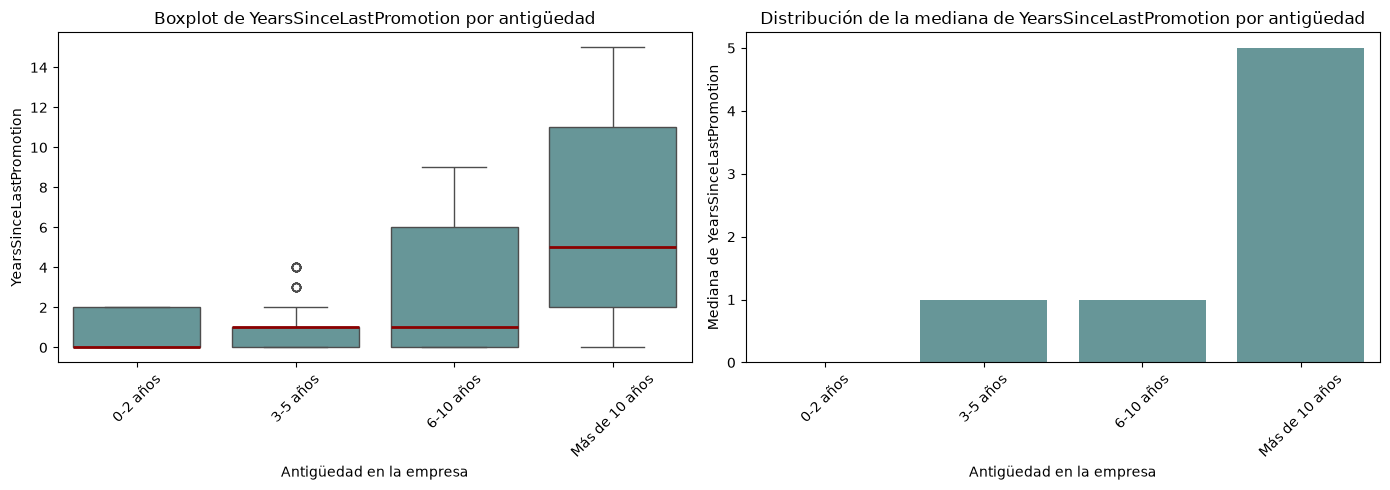

In [19]:
visualizacion_promocion_antiguedad(df_final)

* Al cruzar los años desde el último ascenso con la antigüedad en la empresa, se observa que los valores bajos de `YearsSinceLastPromotion` están muy influidos por los empleados con menor trayectoria en la compañía. 
* En los grupos de menor antigüedad, una mediana baja no necesariamente indica promociones frecuentes, sino que muchos empleados todavía no han tenido tiempo suficiente para ascender. Sin embargo, entre quienes llevan más de 10 años en la empresa, la mediana asciende a 5 años y la dispersión aumenta, lo que apunta a una mayor concentración de empleados con trayectorias más largas sin promoción reciente.

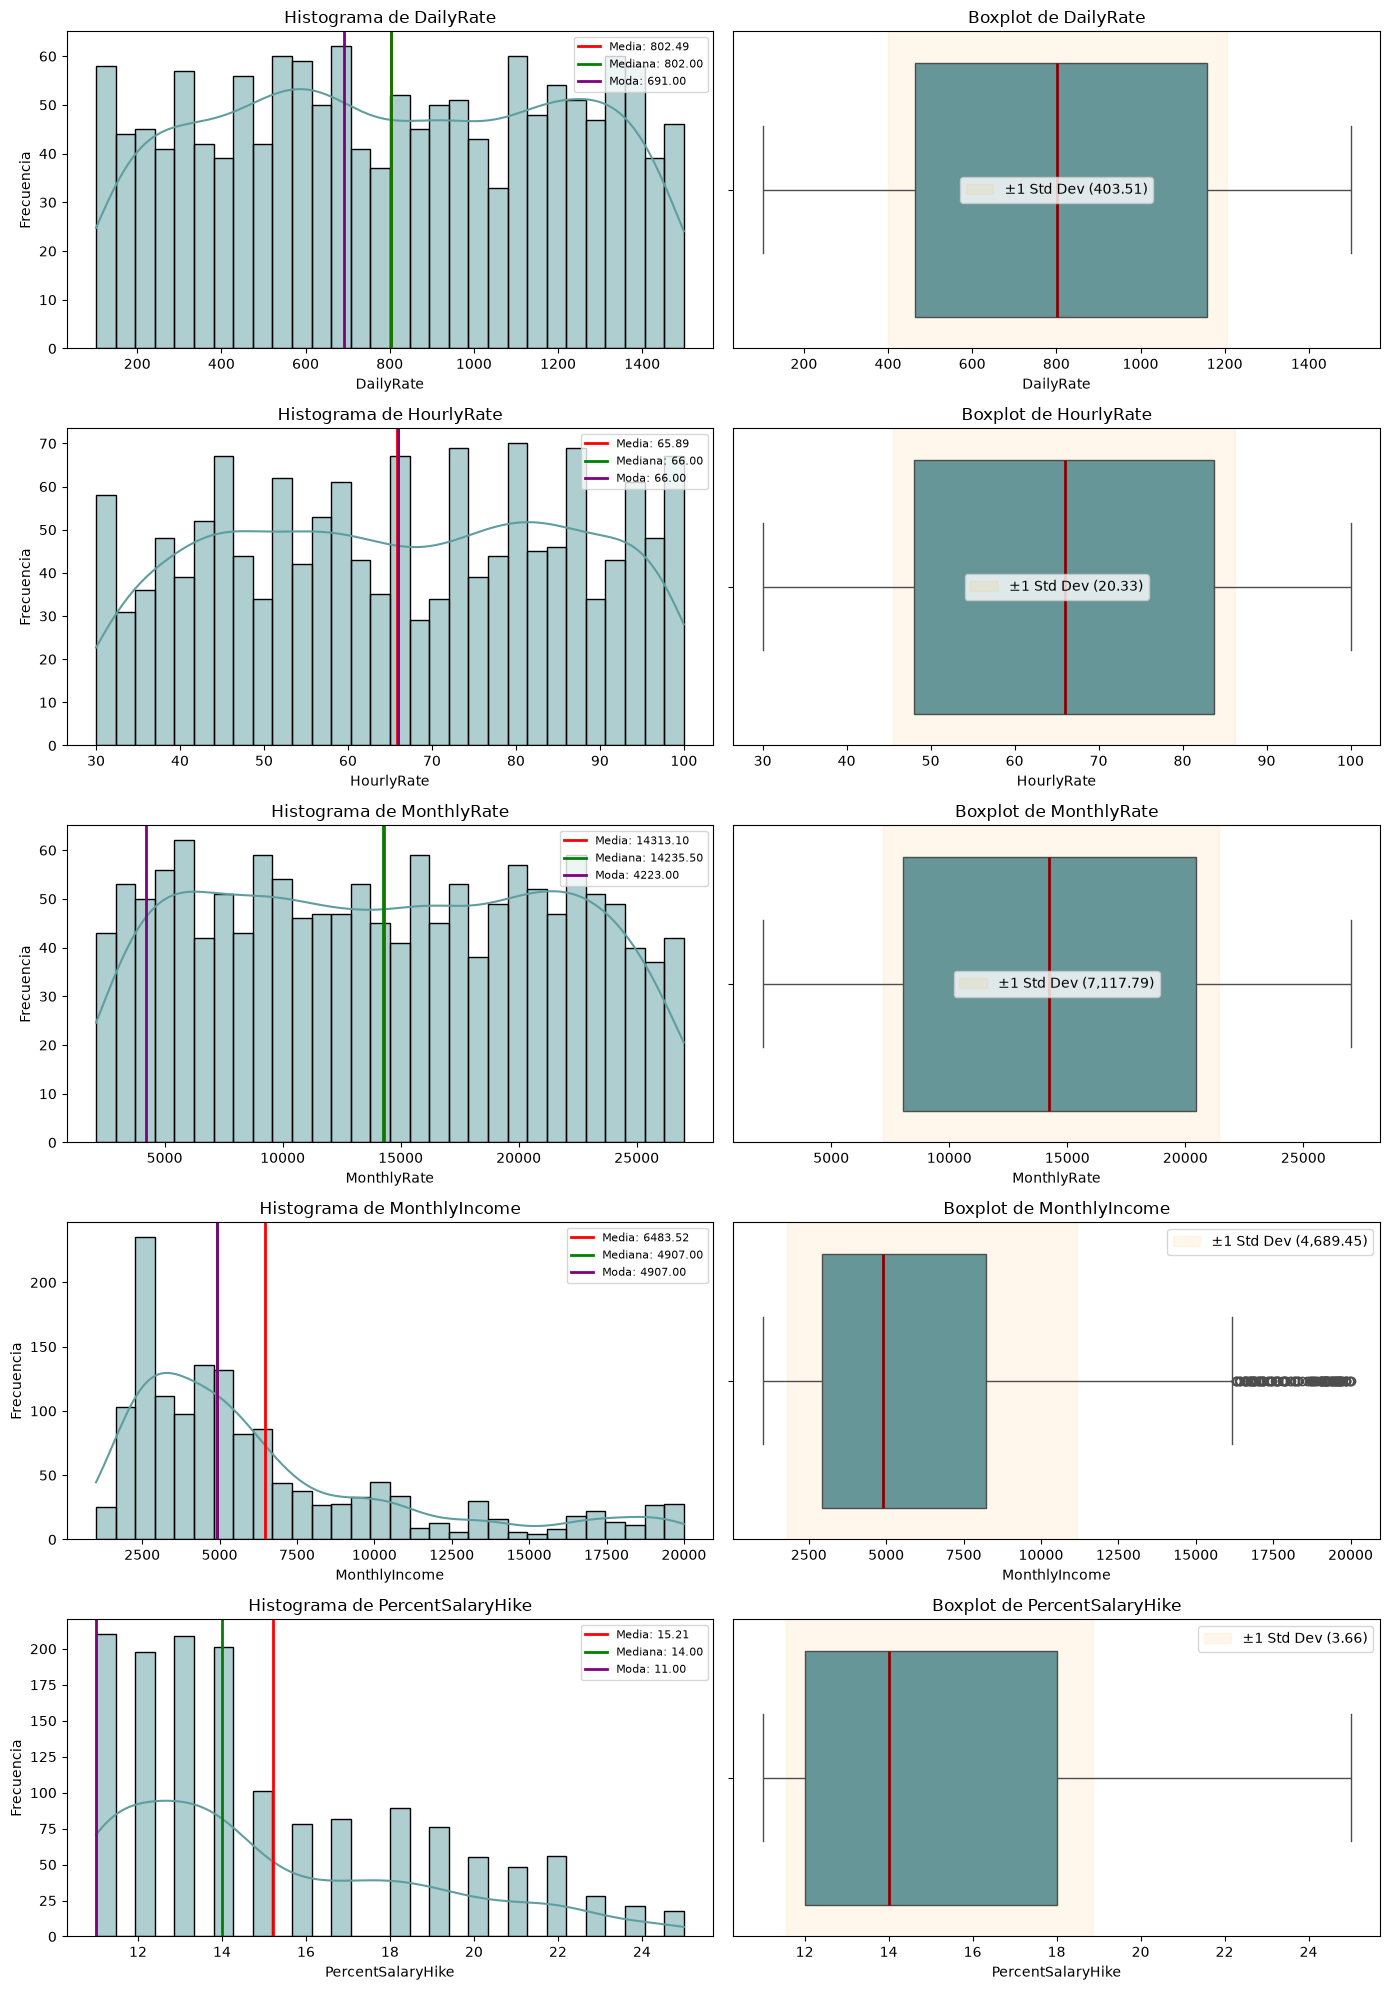

In [20]:
# # Ejecución de la función para variables salario
visualizacion_numericas(df_final, variables_salario)

**Análisis de visualización de variables salario:**
* *`DailyRate`,`HourlyRate`, `MonthlyRate`,`MonthlyIncome` y `PercentSalaryHike`*

- `DailyRate`,`HourlyRate` y `MonthlyRate` son uniformes. No tienen outliers ni sesgo puesto que no representan un salario real, sino un valor de la empresa.
- `MonthlyIncome` está claramente sesgada a la derecha, con outliers claros en los valores altos. Esto es indicativo de sueldos muy altos pero poco comunes, mientras que la mayoría de la plantilla cobra sueldos básicos. Esta diferencia es notoria entre la media (6483.52) y la mediana (4907) que además es igual a la moda.
- `PercentSalaryHike` presenta el mismo tipo de asimetría que la anterior, indicando que las subidas con porcentajes altos son poco comunes, pero no tiene outliers.

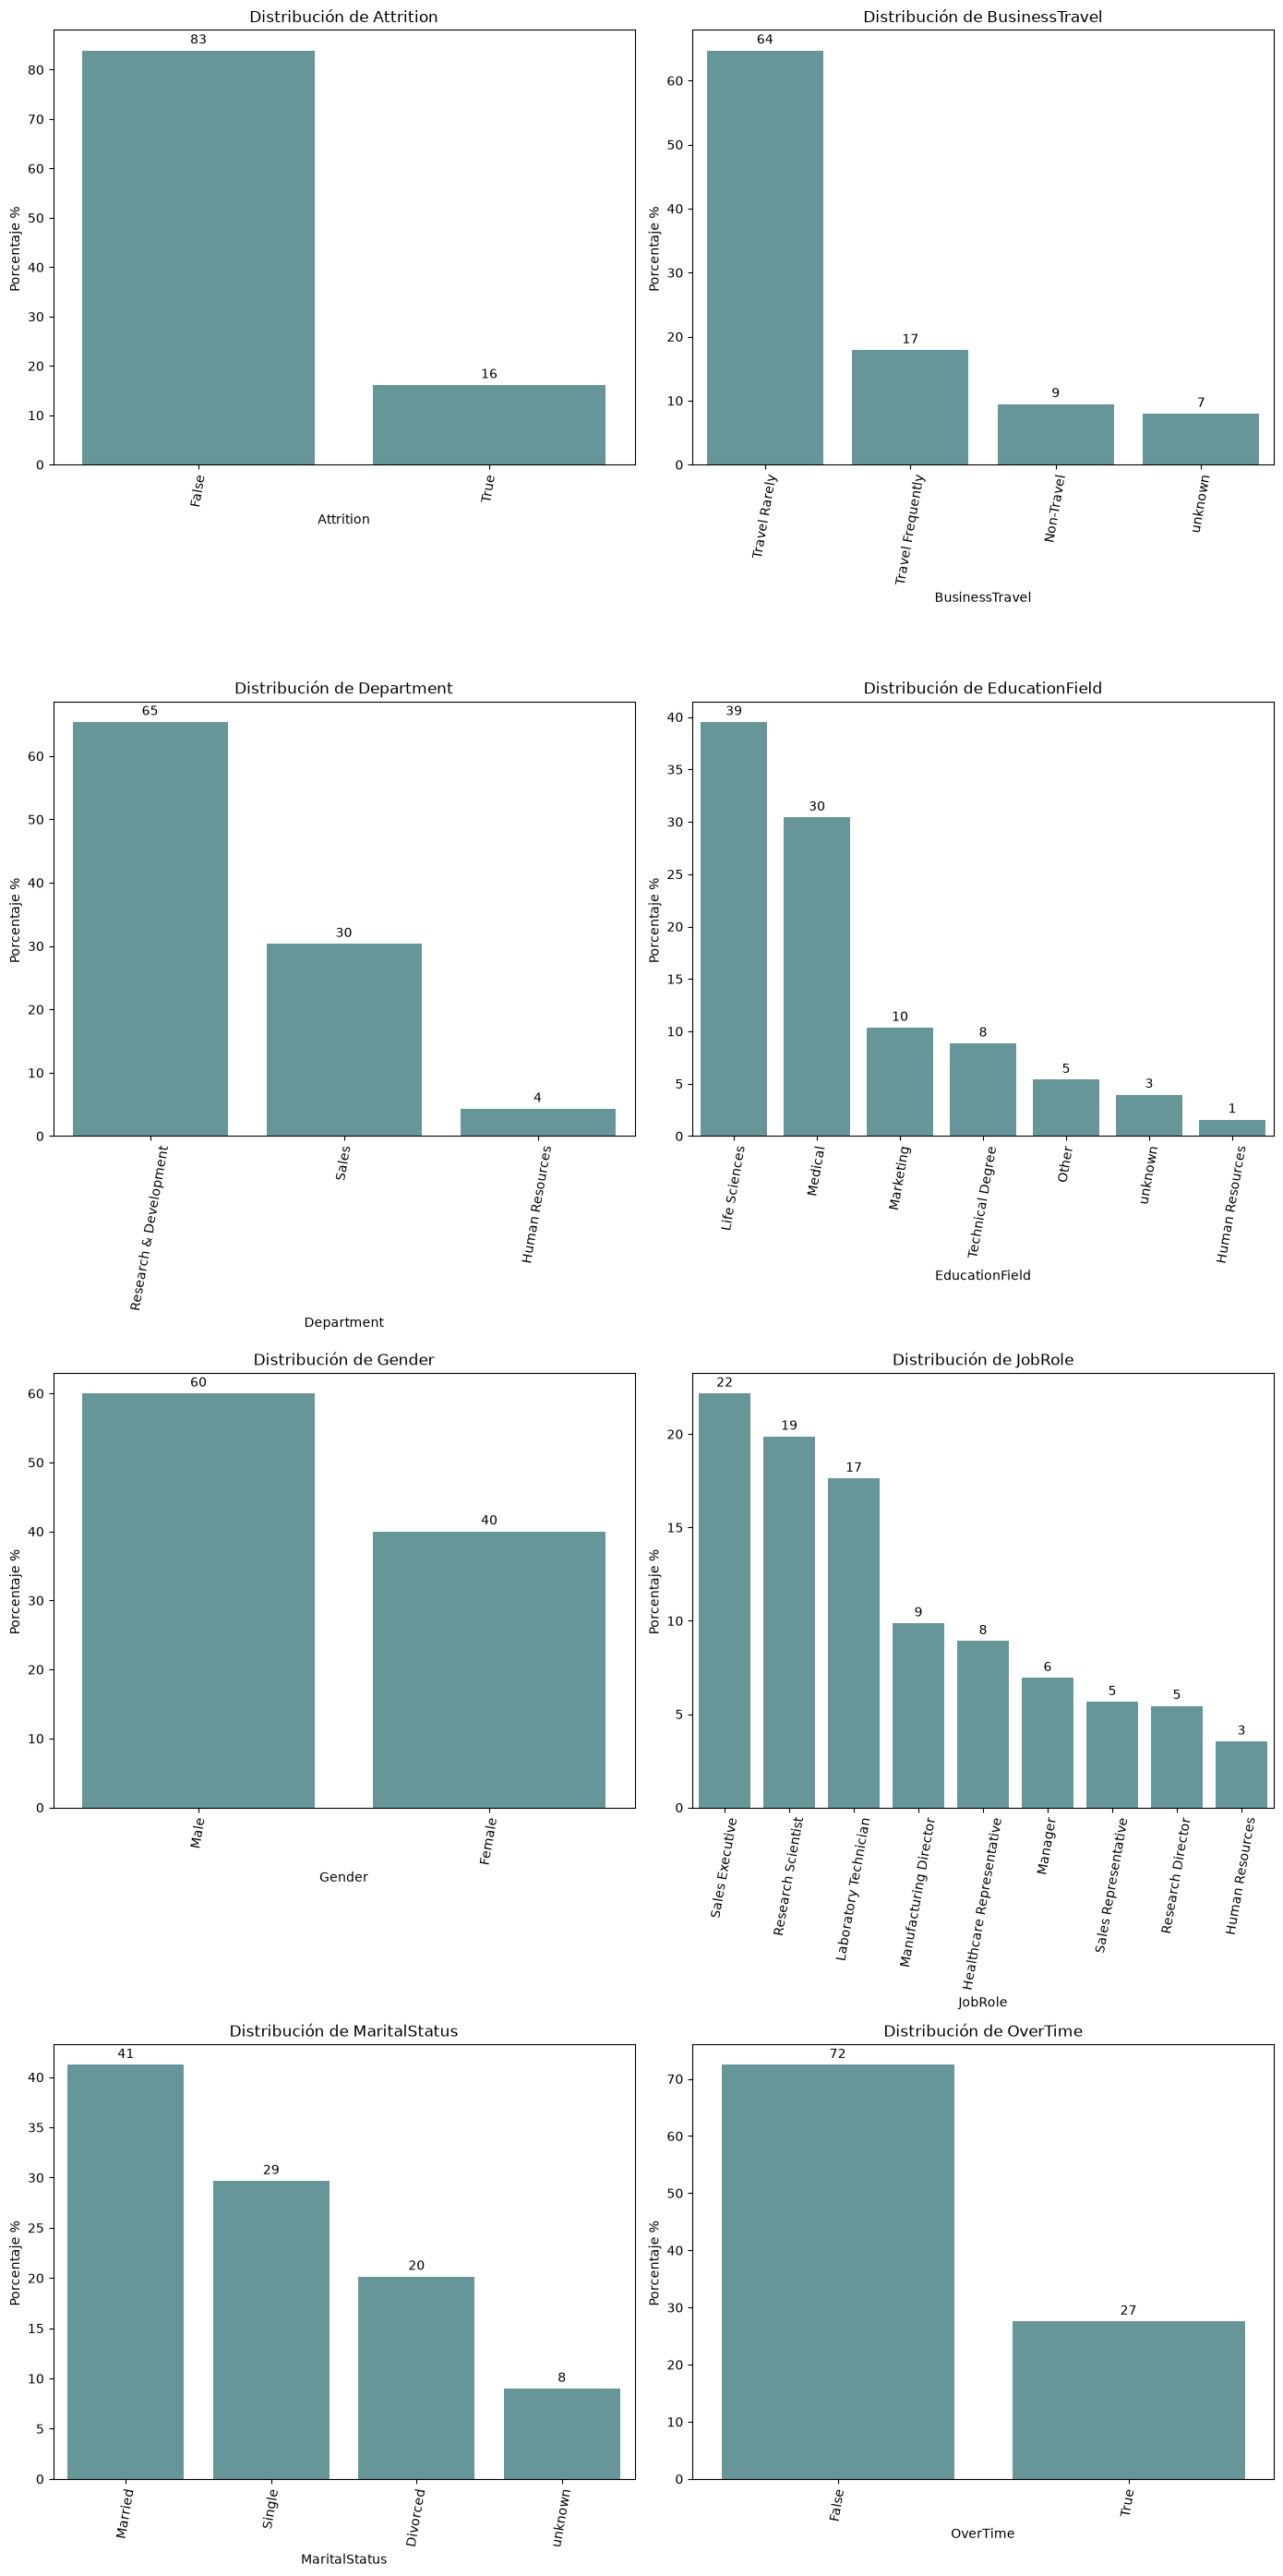

In [21]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14,28))

# Aplanamos los ejes para recorrerlos más fácilmente
axes = axes.flat

for i, columna in enumerate(variables_categoricas):

    # Se presentan las variables categoricas en porcentajes 
    porcentajes = (
        df_final[columna]
        .value_counts(normalize=True)
        .mul(100)
        .reset_index()
    )
    
    porcentajes.columns = [columna, "porcentaje"]
    
    
    orden = df_final[columna].value_counts().index
    
    # Gráfico de barras
    sns.barplot(
        data=porcentajes,
        x=columna,
        y='porcentaje',
        order=orden,
        color= 'cadetblue',
        ax=axes[i]
    )
    
    # Título de las gráficas y los ejes
    axes[i].set_title(f"Distribución de {columna}", fontsize=12)
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel("Porcentaje % ")
    axes[i].tick_params(axis="x", rotation=80)
    
    # Añadir etiquetas numéricas encima de cada barra
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%d", label_type="edge", padding=3)


plt.tight_layout()
plt.show()

**Análisis de visualización de variables categóricas:**

* Los datos observados en estas gráficas son iguales a los ya ofrecidos por las tablas de frecuencias. 